In [1]:
import jax
import jax.numpy as jnp
import jax.scipy.stats as stats
import numpy as np
import optax

from functools import partial
import matplotlib.pyplot as plt

import blackjax
from jax_tqdm import scan_tqdm

observed = 4.
def logdensity_fn(z):
    mean = z**2
    logpdf = stats.norm.logpdf(observed, mean, 0.5) + stats.norm.logpdf(z, 0, 1)
    return jnp.sum(logpdf)

# Build the kernel
step_size = 1e-2
inverse_mass_matrix = jnp.ones((1,))
nuts = blackjax.nuts(logdensity_fn, step_size, inverse_mass_matrix)

# Initialize the state
initial_position = jax.random.normal(jax.random.PRNGKey(0), (2,))
state = nuts.init(initial_position)

# Iterate

rng_key = jax.random.key(0)
step = jax.jit(nuts.step)

@partial(jax.jit, static_argnums=(2,))
def mcmc(rng_key, state, num_samples):
   
    def scan_fn(state, key):
        next_state, _ = step(key, state)
        return next_state, next_state.position

    keys = jax.random.split(rng_key, num_samples)
    return jax.lax.scan(scan_fn, state, keys)

In [4]:
blackjax.irmh.build_kernel()

<function blackjax.mcmc.random_walk.build_irmh.<locals>.kernel(rng_key: jax.Array, state: blackjax.mcmc.random_walk.RWState, logdensity_fn: Callable, proposal_distribution: Callable, proposal_logdensity_fn: Optional[Callable] = None) -> tuple[blackjax.mcmc.random_walk.RWState, blackjax.mcmc.random_walk.RWInfo]>

In [20]:
blackjax.mala.build_kernel()

<function blackjax.mcmc.mala.build_kernel.<locals>.kernel(rng_key: jax.Array, state: blackjax.mcmc.mala.MALAState, logdensity_fn: Callable, step_size: float) -> tuple[blackjax.mcmc.mala.MALAState, blackjax.mcmc.mala.MALAInfo]>

In [23]:
blackjax.elliptical_slice.build_kernel()

TypeError: build_kernel() missing 2 required positional arguments: 'cov_matrix' and 'mean'

In [4]:
from jax.flatten_util import ravel_pytree
ravel_pytree(initial_position,)

(Array([-0.78476596,  0.85644484], dtype=float32),
 <jax._src.util.HashablePartial at 0x7f00b70d76a0>)

In [2]:
out = mcmc(rng_key, state, 2)

In [4]:
?blackjax.nuts

Init signature:
blackjax.nuts(
    logdensity_fn: Callable,
    step_size: float,
    inverse_mass_matrix: Union[blackjax.mcmc.metrics.Metric, jax.Array, Callable[[Union[jax.Array, numpy.ndarray, numpy.bool_, numpy.number, bool, int, float, complex, Iterable[ForwardRef('ArrayLikeTree')], Mapping[Any, ForwardRef('ArrayLikeTree')]]], jax.Array]],
    *,
    max_num_doublings: int = 10,
    divergence_threshold: int = 1000,
    integrator: Callable = <function generate_euclidean_integrator.<locals>.euclidean_integrator at 0x7f7ca9b5c9d0>,
) -> blackjax.base.SamplingAlgorithm
Docstring:     
Implements the (basic) user interface for the nuts kernel.

Examples
--------

A new NUTS kernel can be initialized and used with the following code:

.. code::

    nuts = blackjax.nuts(logdensity_fn, step_size, inverse_mass_matrix)
    state = nuts.init(position)
    new_state, info = nuts.step(rng_key, state)

We can JIT-compile the step function for more speed:

.. code::

    step = jax.jit(nuts.s

In [3]:
out

(HMCState(position=Array([-1.0639087,  1.0152643], dtype=float32), logdensity=Array(-37.45552, dtype=float32), logdensity_grad=Array([-23.347248,  23.101229], dtype=float32)),
 Array([[-0.874254 ,  0.9857494],
        [-1.0639087,  1.0152643]], dtype=float32))

In [34]:
alog = blackjax.hmc(logdensity_fn, 1e-2, inverse_mass_matrix=jnp.ones((1,)), num_integration_steps=10)

In [161]:
results, info = blackjax.window_adaptation(blackjax.hmc, logdensity_fn,initial_step_size=2., num_integration_steps=5).run(rng_key,initial_position, 1000)

In [213]:
results, info = blackjax.chees_adaptation(logdensity_fn, 1).run(rng_key, jnp.ones((1,2)), 1e-1, optim= optax.adam(1e-3))

In [238]:
blackjax.dynamic_hmc(logdensity_fn, 1e-2, inverse_mass_matrix=jnp.ones((1,)))

SamplingAlgorithm(init=<function dynamic_hmc.__new__.<locals>.init_fn at 0x7fb362008ee0>, step=<function dynamic_hmc.__new__.<locals>.step_fn at 0x7fb362008160>)

In [231]:
results.parameters

{'step_size': Array(1.8598825, dtype=float32, weak_type=True),
 'inverse_mass_matrix': Array([1., 1.], dtype=float32),
 'next_random_arg_fn': <function blackjax.adaptation.chees_adaptation.chees_adaptation.<locals>.run.<locals>.<lambda>(i)>,
 'integration_steps_fn': <function blackjax.adaptation.chees_adaptation.chees_adaptation.<locals>.run.<locals>.<lambda>(arg)>}

In [236]:
results.parameters["next_random_arg_fn"](jax.random.PRNGKey(2))

Array([1, 3], dtype=uint32)

In [172]:
State

<function typing.NamedTuple(typename, fields=None, /, **kwargs)>

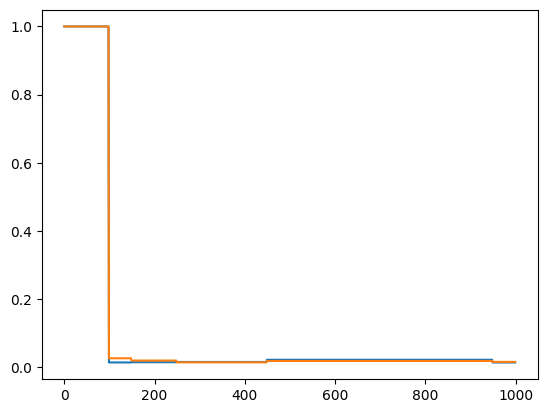

In [163]:
plt.plot(info.adaptation_state.inverse_mass_matrix)

(0.0, 10.0)

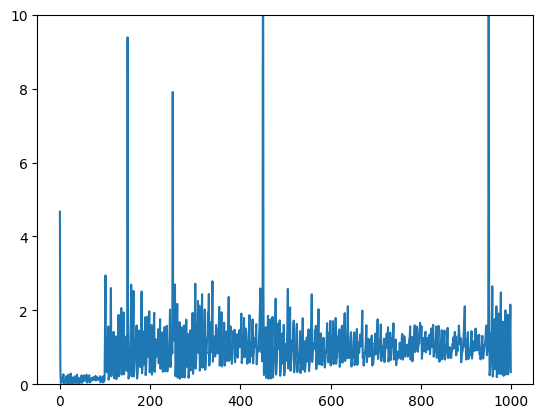

In [164]:
plt.plot(info.adaptation_state.step_size)
plt.ylim(0, 10.)

In [118]:
info._

Array([2.3350646 , 0.2302358 , 0.01669444, 0.01853417, 0.02544983,
       0.03996141, 0.06795491, 0.12141295, 0.12360987, 0.01751511,
       0.03318185, 0.0633719 , 0.11369555, 0.2005863 , 0.3820575 ,
       0.03333635, 0.06405162, 0.07717898, 1.1057799 , 0.18665425],      dtype=float32)

In [91]:
?blackjax.window_adaptation

Signature:
blackjax.window_adaptation(
    algorithm: Union[blackjax.mcmc.hmc.hmc, blackjax.mcmc.nuts.nuts],
    logdensity_fn: Callable,
    is_mass_matrix_diagonal: bool = True,
    initial_step_size: float = 1.0,
    target_acceptance_rate: float = 0.8,
    progress_bar: bool = False,
    **extra_parameters,
) -> blackjax.base.AdaptationAlgorithm
Docstring:
Adapt the value of the inverse mass matrix and step size parameters of
algorithms in the HMC fmaily.

Algorithms in the HMC family on a euclidean manifold depend on the value of
at least two parameters: the step size, related to the trajectory
integrator, and the mass matrix, linked to the euclidean metric.

Good tuning is very important, especially for algorithms like NUTS which can
be extremely inefficient with the wrong parameter values. This function
provides a general-purpose algorithm to tune the values of these parameters.
Originally based on Stan's window adaptation, the algorithm has evolved to
improve performance and qu

In [207]:
results = blackjax.chees_adaptation(logdensity_fn,10).run(rng_key,jax.random.normal(rng_key, (10, 2)), 1e-1, optim=optax.adam(1e-2))

In [79]:
blackjax.ess(results[1].state.position[-50:][None,...])

Array([36.532974, 70.18473 ], dtype=float32)

In [66]:
?blackjax.ess

Signature:
blackjax.ess(
    input_array: Union[jax.Array, numpy.ndarray, numpy.bool_, numpy.number, bool, int, float, complex],
    chain_axis: int = 0,
    sample_axis: int = 1,
) -> jax.Array
Docstring:
Compute estimate of the effective sample size (ess).

Parameters
----------
input_array:
    An array representing multiple chains of MCMC samples. The array must
    contains a chain dimension and a sample dimension.
chain_axis
    The axis indicating the multiple chains. Default to 0.
sample_axis
    The axis indicating a single chain of MCMC samples. Default to 1.

Returns
-------
NDArray of the resulting statistics (ess), with the chain and sample dimensions squeezed.

Notes
-----
The basic ess (:math:`N_{\mathit{eff}}`) diagnostic is computed by:

.. math:: \hat{N}_{\mathit{eff}} = \frac{MN}{\hat{\tau}}

.. math:: \hat{\tau} = -1 + 2 \sum_{t'=0}^K \hat{P}_{t'}

where :math:`M` is the number of chains, :math:`N` the number of draws,
:math:`\hat{\rho}_t` is the estimated _autocorr

In [6]:
@partial(jax.jit, static_argnums=(1,3))
def smc_inference_loop(rng_key, smc_kernel, initial_state, num_samples):
    """Run the temepered SMC algorithm.

    We run the adaptive algorithm until the tempering parameter lambda reaches the value
    lambda=1.

    """

    def one_step(carry, key):
        state, i = carry
        lmbda = i / num_samples
        next_state, _ = smc_kernel(key, state, lmbda)
        
        return (next_state, i +1), next_state.particles
    
    keys = jax.random.split(rng_key, num_samples)
    carry = (initial_state, 0)
    (final_state, _), samples = jax.lax.scan(one_step, carry, keys)
    return final_state, samples

In [8]:
from blackjax.smc import resampling

inv_mass_matrix = jnp.array([1.])

hmc_parameters = dict(
    step_size=1e-1, inverse_mass_matrix=inv_mass_matrix, num_integration_steps=10
)

prior_log_prob = lambda x: stats.norm.logpdf(x, 0, 1)
loglikelihood = lambda x: stats.norm.logpdf(observed, x**2, 0.5)

tempered = blackjax.tempered_smc(
    prior_log_prob,
    loglikelihood,
    blackjax.hmc.build_kernel(),
    blackjax.hmc.init,
    hmc_parameters,
    resampling.systematic,
    num_mcmc_steps=10,
)

rng_key, init_key, sample_key = jax.random.split(rng_key, 3)
initial_position = jax.random.normal(init_key, (1000,1))
initial_smc_state = tempered.init(initial_position)

final_state, smc_samples = smc_inference_loop(sample_key, tempered.step, initial_smc_state, 10)

ValueError: vmap was requested to map its argument along axis 0, which implies that its rank should be at least 1, but is only 0 (its shape is ())

(array([ 34., 159., 215.,  84.,  11.,   2.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,  29.,  93., 206., 140.,  27.]),
 array([-2.29267406, -2.13891053, -1.985147  , -1.83138335, -1.67761981,
        -1.52385628, -1.37009275, -1.21632922, -1.06256557, -0.90880203,
        -0.7550385 , -0.60127497, -0.44751137, -0.29374784, -0.13998428,
         0.01377928,  0.16754285,  0.32130641,  0.47506994,  0.62883353,
         0.78259706,  0.9363606 ,  1.09012413,  1.24388778,  1.39765131,
         1.55141485,  1.70517838,  1.85894191,  2.01270556,  2.1664691 ,
         2.32023263]),
 <BarContainer object of 30 artists>)

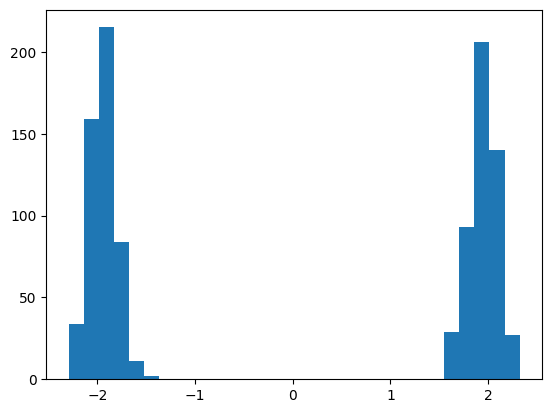

In [ ]:
plt.hist(smc_samples[-1], bins=30)

In [ ]:
def logdensity_fn(x, y, Sigma):
    """
    Log-pdf of ``(x, y) ~ MvNormal(0, Sigma)``.
    """
    z = jnp.concatenate([x, y])
    return jax.scipy.stats.multivariate_normal.logpdf(
        x=z,
        mean=jnp.zeros_like(z),
        cov=Sigma
    )

# Specific example with x.shape == y.shape == (2,)
Sigma = jnp.array([
    [1., 0., .8, 0.],
    [0., 1., 0., .8],
    [.8, 0., 1., 0.],
    [0., .8, 0., 1.]
])

def logdensity(x, y):
    return logdensity_fn(x, y, Sigma=Sigma)

In [ ]:
# MCMC initializers for each set of paramters
mwg_init_x = blackjax.rmh.init
mwg_init_y = blackjax.hmc.init

# MCMC updaters
mwg_step_fn_x = blackjax.rmh.build_kernel()
mwg_step_fn_y = blackjax.hmc.build_kernel()  # default integrator, etc.

In [ ]:
parameters = {
    "x": {
        "transition_generator": blackjax.mcmc.random_walk.normal(.2 * jnp.eye(2))
    },
    "y": {
        "inverse_mass_matrix": jnp.array([1., 1.]),
        "num_integration_steps": 100,
        "step_size": 1e-2
    }
}

initial_state = {
    "x": mwg_init_x(
        position=jnp.array([0., 0.]),
        logdensity_fn=lambda x: logdensity(x=x, y=jnp.array([0., 0.]))
    ),
    "y": mwg_init_y(
        position=jnp.array([0., 0.]),
        logdensity_fn=lambda y: logdensity(y=y, x=jnp.array([0., 0.]))
    )
}

init_fn = {
    "x": partial(mwg_init_x, position=jnp.array([0., 0.])),
    "y": partial(mwg_init_y, position=jnp.array([0., 0.]))
}

step_fn = {
    "x": partial(mwg_step_fn_x),
    "y": partial(mwg_step_fn_y)
}


In [ ]:
def mwg_kernel_general(rng_key, state, logdensity_fn, step_fn, init, parameters):
    rng_keys = jax.random.split(rng_key, num=len(state))
    rng_keys = dict(zip(state.keys(), rng_keys))

    # avoid modifying argument state as JAX functions should be pure
    state = state.copy()

    for k in state.keys():
        # logdensity of component k conditioned on all other components in state
        def logdensity_k(value):
            kwargs = {_k: state[_k].position for _k in state.keys()}
            kwargs[k] = value
            return logdensity_fn(**kwargs)

        # give state[k] the right log_density
        state[k] = init[k](
            position=state[k].position,
            logdensity_fn=logdensity_k
        )

        # update state[k]
        state[k], _ = step_fn[k](
            rng_key=rng_keys[k],
            state=state[k],
            logdensity_fn=logdensity_k,
            **parameters[k]
        )

    return state

mwg_kernel = partial(mwg_kernel_general, logdensity_fn=logdensity, step_fn=step_fn, init=init_fn, parameters=parameters)

In [ ]:
mwg_kernel(rng_key, initial_state)

{'x': RWState(position=Array([-0.08245948,  0.44156176], dtype=float32), logdensity=Array(-2.9343476, dtype=float32)),
 'y': HMCState(position=Array([-0.25091833,  1.0993989 ], dtype=float32), logdensity=Array(-3.575749, dtype=float32), logdensity_grad=Array([ 0.51375216, -2.0726376 ], dtype=float32))}

In [ ]:

def sampling_loop(rng_key, initial_state, parameters, num_samples):

    def one_step(state, rng_key):
        state = mwg_kernel(
            rng_key=rng_key,
            state=state,
            parameters=parameters
        )
        positions = {k: state[k].position for k in state.keys()}
        return state, positions

    keys = jax.random.split(rng_key, num_samples)
    _, positions = jax.lax.scan(one_step, initial_state, keys)

    return positions

In [ ]:
rng_key, sample_key = jax.random.split(rng_key)

In [ ]:
positions = sampling_loop(sample_key, initial_state, parameters, 10)

In [ ]:
sampler = blackjax.rmh(logdensity_fn=logdensity_fn, proposal_generator=blackjax.mcmc.random_walk.normal(.2 * jnp.eye(2)))

In [ ]:
state = sampler.init(jnp.array([0., 0.]))

In [ ]:
sampler.step(rng_key, state)

(RWState(position=Array([-0.00990007, -0.1423136 ], dtype=float32), logdensity=Array(-65.97484, dtype=float32)),
 RWInfo(acceptance_rate=Array(1., dtype=float32), is_accepted=Array(True, dtype=bool), proposal=RWState(position=Array([-0.00990007, -0.1423136 ], dtype=float32), logdensity=Array(-65.97484, dtype=float32))))

In [ ]:
kernel = blackjax.rmh.build_kernel()

In [ ]:
import blackjax

In [ ]:
from blackjax.adaptation.step_size import dual_averaging_adaptation
from blackjax.adaptation.mass_matrix import welford_algorithm
adapt_init, adapt_step, adapt_final = dual_averaging_adaptation(
        0.8, t0=10.,gamma=0.05, kappa=0.99
)

observed = 4.
def logdensity_fn(z):
    mean = z**2
    logpdf = stats.norm.logpdf(observed, mean, 0.5) + stats.norm.logpdf(z, 0, 1)
    return jnp.sum(logpdf)

In [ ]:
kernel = blackjax.rmh.build_kernel()

In [96]:
adapt_init, adapt_step, adapt_final = welford_algorithm(is_diagonal_matrix=True)

In [97]:
kernel(jax.random.key(1), state, logdensity_fn, transition_generator=blackjax.mcmc.random_walk.normal(1.))

(RWState(position=Array([2.2646842], dtype=float32), logdensity=Array(-6.2574825, dtype=float32)),
 RWInfo(acceptance_rate=Array(5.3543292e-05, dtype=float32), is_accepted=Array(False, dtype=bool), proposal=RWState(position=Array([2.2646842], dtype=float32), logdensity=Array(-6.2574825, dtype=float32))))

In [117]:
state = blackjax.rmh.init(jnp.array([0.]), logdensity_fn=logdensity_fn)
adapt_state = adapt_init(1)
step_size = 2.34

acceptance_rate = 1.
for i in range(500):
    rng_key, subkey = jax.random.split(rng_key)
    state, info = kernel(subkey, state, logdensity_fn=logdensity_fn, transition_generator=lambda k, x: x + step_size*jax.random.normal(k, x.shape))
    adapt_state = adapt_step(adapt_state, state.position)
    #print(adapt_state)
    if i > 20:
        step_size = 2.34* adapt_state.m2  / (adapt_state.sample_size-1)
    
    acceptance_rate = 0.5 * acceptance_rate + 0.5 * info.acceptance_rate
    print(step_size, acceptance_rate)

    
    

2.34 1.0
2.34 1.0
2.34 0.5
2.34 0.25
2.34 0.125
2.34 0.0625
2.34 0.03129978
2.34 0.015650507
2.34 0.50782526
2.34 0.25391263
2.34 0.62695634
2.34 0.31347817
2.34 0.15673909
2.34 0.078370534
2.34 0.039185267
2.34 0.042717844
2.34 0.029892378
2.34 0.014963585
2.34 0.5074818
2.34 0.7537409
2.34 0.37687045
[5.8753047] 0.18843523
[6.016562] 0.09421761
[6.1129894] 0.047108807
[6.1889772] 0.5235544
[6.234465] 0.2617772
[6.255582] 0.1308886
[6.257189] 0.0654443
[6.243166] 0.03272215
[6.216629] 0.016361075
[6.1800895] 0.0081879
[6.1355834] 0.00409395
[6.0847683] 0.002046975
[6.131459] 0.5010235
[6.162588] 0.25051174
[6.1805263] 0.12525587
[6.1872716] 0.062627934
[6.184515] 0.031313967
[6.452128] 0.515657
[6.685051] 0.25782865
[6.887381] 0.41425133
[6.9744453] 0.5716511
[7.0457845] 0.28582555
[7.1032653] 0.14291278
[7.1485195] 0.07145639
[7.189319] 0.46970072
[7.2200327] 0.23485036
[7.241813] 0.11742518
[7.2556763] 0.05871259
[7.262519] 0.029356295
[7.2631345] 0.014678148
[7.2582264] 0.007343549

In [145]:
adapt_init, adapt_step, adapt_final = dual_averaging_adaptation(0.8)

In [146]:
adapt_state = adapt_init(2.34)
adapt_state

DualAveragingAdaptationState(log_step_size=Array(0.8501509, dtype=float32, weak_type=True), log_step_size_avg=0.0, step=1, avg_error=0.0, mu=Array(3.152736, dtype=float32, weak_type=True))

In [147]:
adapt_state.mu

Array(3.152736, dtype=float32, weak_type=True)

In [154]:
state = blackjax.rmh.init(jnp.array([0.]), logdensity_fn=logdensity_fn)
adapt_state = adapt_init(2.34)
step_size = 2.34

acceptance_rate = 1.
for i in range(500):
    rng_key, subkey = jax.random.split(rng_key)
    state, info = kernel(subkey, state, logdensity_fn=logdensity_fn, transition_generator=lambda k, x: x + step_size*jax.random.normal(k, x.shape))
    acceptance_rate = 0.9 * acceptance_rate + 0.1 * info.acceptance_rate
    adapt_state = adapt_step(adapt_state, info.acceptance_rate)
    #print(adapt_state)
    step_size = jnp.exp(adapt_state.log_step_size_avg)
    
    print(step_size, acceptance_rate)

    
    

2.3399997 1.0
11.421476 0.9
8.412673 0.90999997
8.286092 0.81899995
4.0538936 0.73709995
1.3519729 0.6633899
0.35770187 0.5970585
0.08169388 0.63735265
0.031045439 0.6412839
0.013943886 0.6601904
0.0076575903 0.69417137
0.0052967966 0.7066802
0.004003841 0.7336923
0.0034697643 0.76032305
0.003372767 0.78429073
0.0035853048 0.80175537
0.0040279767 0.8215798
0.0047969907 0.8394218
0.005985004 0.85547966
0.0077512073 0.86696
0.0102514895 0.87597424
0.013735034 0.88837683
0.01881565 0.8995392
0.02624222 0.8883938
0.03515894 0.8933834
0.04724908 0.90404505
0.064576335 0.91202265
0.089153044 0.9208204
0.12453389 0.92873836
0.17562261 0.91433805
0.23863249 0.83073705
0.2721517 0.84766334
0.3192757 0.7837945
0.33030552 0.7199776
0.3026239 0.74319124
0.2879964 0.7021831
0.25447145 0.6326505
0.19933909 0.66938543
0.1653673 0.68748516
0.1409405 0.71873665
0.12596537 0.6873734
0.10728782 0.7186361
0.095633045 0.73750347
0.087607756 0.7637531
0.0833375 0.7308828
0.075850435 0.75779456
0.07160863 0.

KeyboardInterrupt: 

In [ ]:
state.position

Array([-1.9947491], dtype=float32)

In [ ]:
info

RWInfo(acceptance_rate=Array(0.6346985, dtype=float32), is_accepted=Array(True, dtype=bool), proposal=RWState(position=Array([-0.15393834, -0.17727847], dtype=float32), logdensity=Array(-65.438126, dtype=float32)))

In [ ]:
from blackjax.adaptation import window_adaptation, meads_adaptation, pathfinder_adaptation

In [16]:
from blackjax.adaptation.step_size import dual_averaging_adaptation, find_reasonable_step_size
from blackjax.adaptation.base import AdaptationInfo, AdaptationResults 
from blackjax.base import AdaptationAlgorithm


In [13]:

def step_size_adaption(
    algorithm : blackjax.rmh,
    logdensity_fn,
    target_acceptance_rate: float = 0.23,
    inital_step_size: float = 2.34,
    t0 = 10,
    gamma = 0.05,
    kappa = 0.75,
    **kwargs
):
    mcmc_kernel = algorithm.build_kernel()
    adapt_init, adapt_step, adapt_final = dual_averaging_adaptation(
        target_acceptance_rate, t0=t0,gamma=gamma,kappa=kappa,
    )
    
    def one_step(carry, key):
        state, adaption_state = carry
        step_size = jnp.exp(adaption_state.log_step_size)
        transition_generator = lambda k, x: x + step_size*jax.random.normal(k, x.shape)
        state, info = mcmc_kernel(key, state, logdensity_fn, transition_generator, **kwargs)
        adaption_state = adapt_step(adaption_state, info.acceptance_rate)
        return (state, adaption_state), AdaptationInfo(state, info, adaption_state)
    
    def run(rng_key, position, num_steps):
        initial_state = algorithm.init(position, logdensity_fn)
        init_adaptiation_state = adapt_init(inital_step_size)
        
        keys = jax.random.split(rng_key, num_steps)
        init_carry = (initial_state, init_adaptiation_state)
        (final_state, final_adaptation_state), info = jax.lax.scan(one_step, init_carry, keys)
        step_size = adapt_final(final_adaptation_state)
        parameters = {
            "step_size": step_size
        }
        result = AdaptationResults(final_state, parameters)
        return result, info
    
    return AdaptationAlgorithm(run)

In [14]:
blackjax.dynamic_hmc.init(jnp.array([0.]), logdensity_fn, jax.random.PRNGKey(0))

DynamicHMCState(position=Array([0.], dtype=float32), logdensity=Array(-33.14473, dtype=float32), logdensity_grad=Array([0.], dtype=float32), random_generator_arg=Array([0, 0], dtype=uint32))

In [54]:
state = blackjax.rmh(logdensity_fn, proposal_generator=blackjax.mcmc.random_walk.normal(1.)).init(jnp.array([0.]), logdensity_fn)

def f(step_size, key):
    _, info = blackjax.rmh(logdensity_fn, proposal_generator=blackjax.mcmc.random_walk.normal(step_size)).step(key, state)
    return jnp.mean((info.acceptance_rate - 0.28)**2)

In [57]:
jax.grad(f)(.1, jax.random.PRNGKey(2))*10000

Array(0., dtype=float32, weak_type=True)

In [62]:
jnp.dot(jnp.ones((1,10)), jnp.ones((10,)))

Array([10.], dtype=float32)

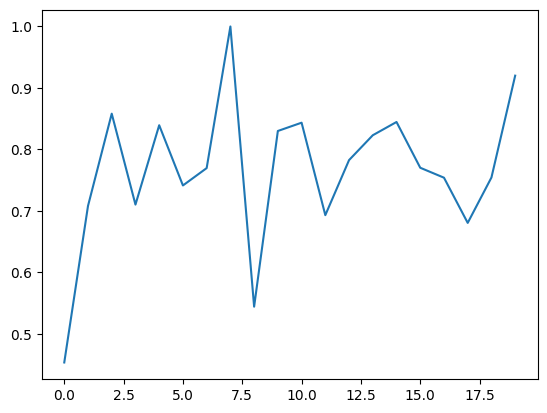

In [15]:
acceptance_rate = step_size_adaption(blackjax.rmh, logdensity_fn, target_acceptance_rate=0.8).run(rng_key, jnp.array([0., 0.]), 100)[1][1].acceptance_rate
# Windowed averaging
acceptance_rate = acceptance_rate.reshape(-1, 5).mean(axis=1)
plt.plot(acceptance_rate)

In [1]:
from probjax.inference.kernels.adaptation import square_root_algorithm
import jax 
import jax.numpy as jnp

In [2]:
init, step, final = square_root_algorithm(True)

In [3]:
A = jax.random.normal(jax.random.PRNGKey(0), (2,2))
xs = (A @ jax.random.normal(jax.random.PRNGKey(0), (2,2000))).T

In [4]:
state = init(2)

In [5]:
state

SquareRootState(mean=Array([0., 0.], dtype=float32), L=Array([0., 0.], dtype=float32), sample_size=0)

In [6]:
for i in range(2000):
    state = jax.jit(step)(state, xs[i])

In [7]:
state

SquareRootState(mean=Array([-0.01349532, -0.00675756], dtype=float32), L=Array([7734.111  ,  817.76385], dtype=float32), sample_size=Array(2000, dtype=int32, weak_type=True))

In [8]:
final(state)

(Array([1.9669749 , 0.63959867], dtype=float32),
 Array(2000, dtype=int32, weak_type=True),
 Array([-0.01349532, -0.00675756], dtype=float32))

In [14]:
final(state)[0]**2

Array([3.8689902 , 0.40908647], dtype=float32)

In [15]:
jnp.cov(xs.T)

Array([[3.866234  , 1.0399146 ],
       [1.0399146 , 0.40881425]], dtype=float32)

In [38]:
jnp.linalg.cholesky(A@A.T)

Array([[1.9667284, 0.       ],
       [0.5191399, 0.3634105]], dtype=float32)

In [29]:
jnp.cov(xs.T)

Array([[3.866229  , 1.0399135 ],
       [1.0399135 , 0.40881377]], dtype=float32)

In [230]:
jnp.mean(xs, axis=0)

Array([-0.32914475, -0.15926543], dtype=float32)

In [196]:
import jax.numpy as jnp
from jax import jit


def cholesky_update(L, u, multiplier=1.0):
    """
    Update the Cholesky decomposition of a matrix after a rank-1 update i.e.
    
    C = L @ L.T + multiplier * u @ u.T

    Args:
    L: A [D, D] lower triangular matrix, the Cholesky factor of the original matrix.
    u: A [D,] vector, the update vector.
    multiplier: A scalar, the multiplier for the rank-1 update.

    Returns:
    The updated [D, D] lower triangular matrix.
    """
    D = L.shape[0]
    u = u * multiplier
    indices = jnp.arange(D)
    
    def body_fun(i, vals):
        L, u = vals
        r = jnp.sqrt(L[i, i]**2 + u[i]**2)
        c = r / L[i, i]
        s = u[i] / L[i, i]
        L = L.at[i, i].set(r)

        mask = indices > i
        col_update = (L[:, i] + s * u) / c
        col_update = jnp.where(mask, col_update, L[:,i])
        L = L.at[:, i].set(col_update)
        u_update = c * u - s * L[:, i]
        u = jnp.where(mask, u_update, u)

        return (L, u)
    
    L,u = jax.lax.fori_loop(0, D, body_fun, (L,u))        
    
    return L

def cholesky_outer_product_update(L, u, v, alpha=1.0):
    """
    Update the Cholesky decomposition L to reflect the addition of alpha * u * v.T.
    """
    D = L.shape[0]

    for i in range(D):
        # Extract the i-th component of v as a scalar
        vi = v[i]
        # Scale vector u by vi (element of v) for this specific update
        ui_scaled = u * vi
        # Apply the rank-1 update with the scaled vector ui_scaled
        L = cholesky_update(L, ui_scaled, alpha)
        
    return L



xs = jax.random.normal(jax.random.PRNGKey(0), (5,11))
cov = jnp.dot(xs[:,:10], xs[:,:10].T) 
L = jnp.linalg.cholesky(cov)


cov2 = jnp.dot(xs, xs.T) 



In [197]:
L_update = cholesky_update(L, xs[:, 11], 1.0)

In [198]:
L_update @ L_update.T

Array([[11.396102 ,  1.4202132, -4.365415 , -4.2269616,  0.5449884],
       [ 1.4202132,  9.427918 , -2.0319934,  5.472699 ,  0.6571564],
       [-4.365415 , -2.0319934, 13.192084 , -1.0636322, -1.8403599],
       [-4.2269616,  5.472699 , -1.0636322, 19.180166 , -0.2961701],
       [ 0.5449884,  0.6571564, -1.8403599, -0.2961701, 10.947719 ]],      dtype=float32)

In [199]:
cov2

Array([[11.396103  ,  1.4202135 , -4.365415  , -4.2269616 ,  0.5449885 ],
       [ 1.4202135 ,  9.427918  , -2.0319932 ,  5.4726996 ,  0.65715647],
       [-4.365415  , -2.0319932 , 13.192084  , -1.0636322 , -1.8403602 ],
       [-4.2269616 ,  5.4726996 , -1.0636322 , 19.180168  , -0.29616982],
       [ 0.5449885 ,  0.65715647, -1.8403602 , -0.29616982, 10.947719  ]],      dtype=float32)

In [201]:
u = jax.random.normal(jax.random.PRNGKey(0), (5,))
v = jax.random.normal(jax.random.PRNGKey(1), (5,))

cov2 + jnp.outer(u, v)

Array([[11.575927  ,  1.2380183 , -4.3861217 , -4.158175  ,  0.5774758 ],
       [ 0.19166052, 10.672669  , -1.890526  ,  5.002752  ,  0.43520457],
       [-4.6249332 , -1.7690535 , 13.221968  , -1.1629034 , -1.887245  ],
       [-3.0312283 ,  4.261201  , -1.2013202 , 19.637562  , -0.08014713],
       [ 0.7790214 ,  0.42003793, -1.8673089 , -0.20664726, 10.99      ]],      dtype=float32)

In [202]:
cholesky_outer_product_update(L, u, v, 1.0) @ cholesky_outer_product_update(L, u, v, 1.0).T

Array([[11.084974  ,  1.2141103 , -4.0834823 , -2.3820157 ,  0.21816264],
       [ 1.2141103 , 12.566021  , -1.6105844 ,  1.1984044 ,  0.33098096],
       [-4.0834823 , -1.6105844 , 12.953423  , -3.1292994 , -1.5520617 ],
       [-2.3820157 ,  1.1984044 , -3.1292994 , 17.465683  ,  1.8259418 ],
       [ 0.21816264,  0.33098096, -1.5520617 ,  1.8259418 , 10.608074  ]],      dtype=float32)

In [130]:
cholesky_update(L, xs[:, 11], 1.0) @ cholesky_update(L, xs[:, 11], 1.0)

Array([[13.539331,  0.      ],
       [12.779797, 16.723604]], dtype=float32)

In [134]:
cov2

Array([[13.112862,  6.851538],
       [ 6.851538, 17.933516]], dtype=float32)